In [12]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay

In [13]:
# Imported Straight from the UC Irvine website
# fetch dataset 
cdc_diabetes_health_indicators = fetch_ucirepo(id=891) 
# data (as pandas dataframes) 
X = cdc_diabetes_health_indicators.data.features 
y = cdc_diabetes_health_indicators.data.targets

# metadata 
print("--- Dataset Metadata ---")
print(cdc_diabetes_health_indicators.metadata) 
print("\n--- Variable Information ---")
print(cdc_diabetes_health_indicators.variables) 

df = X.copy()
df["Diabetes"] = y 

--- Dataset Metadata ---
{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_val

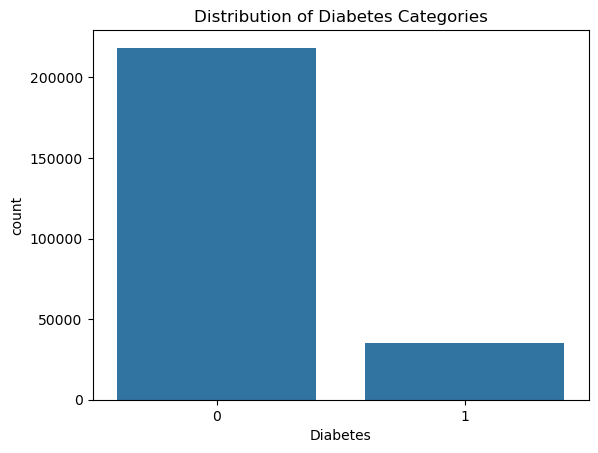

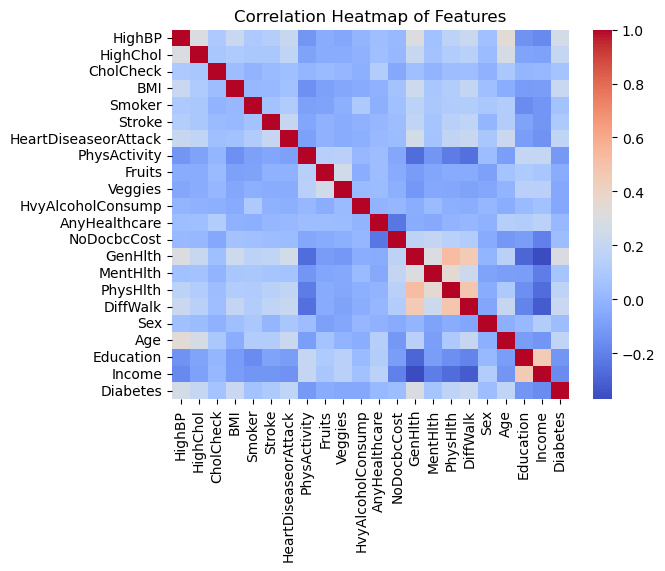

In [14]:
# DATA VISUALIZATION

sns.countplot(x=df["Diabetes"])
plt.title("Distribution of Diabetes Categories")
plt.show()

sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap of Features")
plt.show()

df['Diabetes_Status'] = df['Diabetes'].astype(int).astype('category').cat.rename_categories({
    0: 'No Diabetes', 
    1: 'Diabetes' 
})

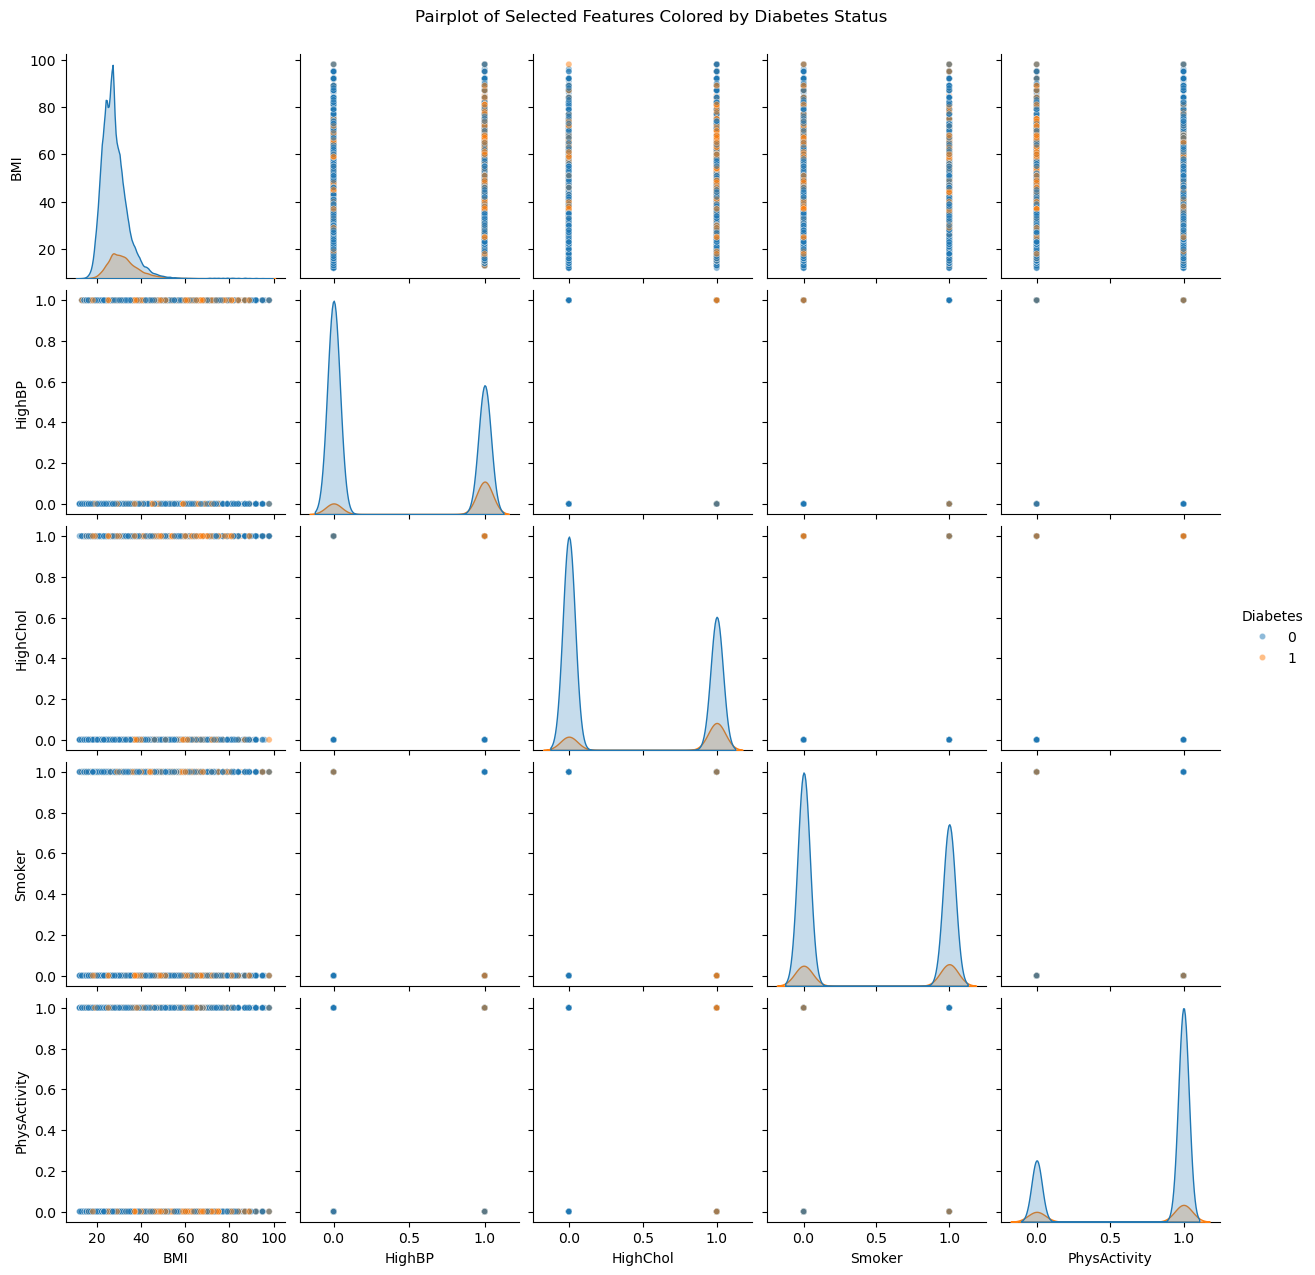

In [14]:
# Pairplot for selected features. On it owns cell because it takes a long time.
selected_features = ['BMI', 'HighBP', 'HighChol', 'Smoker', 'PhysActivity', 'Diabetes']
sns.pairplot(
 df[selected_features],
  hue='Diabetes',
 diag_kind='kde',
 plot_kws={'alpha': 0.5, 's': 20}
)
plt.suptitle("Pairplot of Selected Features Colored by Diabetes Status", y=1.02)
plt.show()


In [6]:
# --- DATA PREPROCESSING ---

# Encode Target Variable
y = y.iloc[:, 0]
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Scale Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# plit Data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
X_trainV, X_val, y_trainV, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)


print("\n--- Preprocessing Complete ---")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val:", X_val.shape, f"y_val:", y_val.shape)
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Printing because I thought it will include 3 labels and it Uses 1 for pre-diabetes/diabetes
print(f"Unique classes in y_train:", np.unique(y_train))
print(f"Unique classes in y_test:", np.unique(y_test))


--- Preprocessing Complete ---
X_train shape: (202944, 21), y_train shape: (202944,)
X_val: (20295, 21) y_val: (20295,)
X_test shape: (50736, 21), y_test shape: (50736,)
Unique classes in y_train: [0 1]
Unique classes in y_test: [0 1]



--- Starting Model 1: Neural Network ---
Epoch 1/20
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8555 - loss: 0.3414 - val_accuracy: 0.8650 - val_loss: 0.3143
Epoch 2/20
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 2s 968us/step - accuracy: 0.8663 - loss: 0.3157 - val_accuracy: 0.8662 - val_loss: 0.3137
Epoch 3/20
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8667 - loss: 0.3134 - val_accuracy: 0.8670 - val_loss: 0.3129
Epoch 4/20
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8676 - loss: 0.3107 - val_accuracy: 0.8661 - val_loss: 0.3131
Epoch 5/20
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 2s 961us/step - accuracy: 0.8671 - loss: 0.3117 - val_accuracy: 0.8654 - val_loss: 0.3115
Epoch 6/20
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 2s 987us/step - accuracy: 0.8670 - loss: 0.3122 - val_accuracy: 0.8678 - val_loss: 0.3108
Epoch 7/20
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 2s 939us/step - accuracy: 0.8671 - loss: 0.3117 - val_accuracy: 0.8670 - val_loss: 0.3102
Epoch 8/20
1586/1586 ━━━━━━━━━━━━━━━━━━━

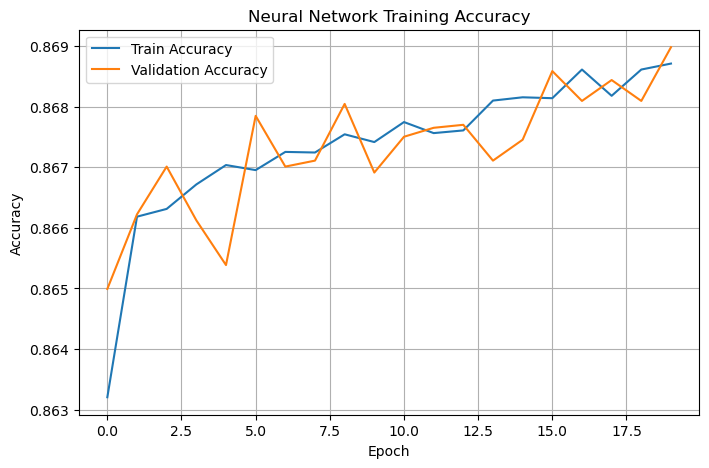

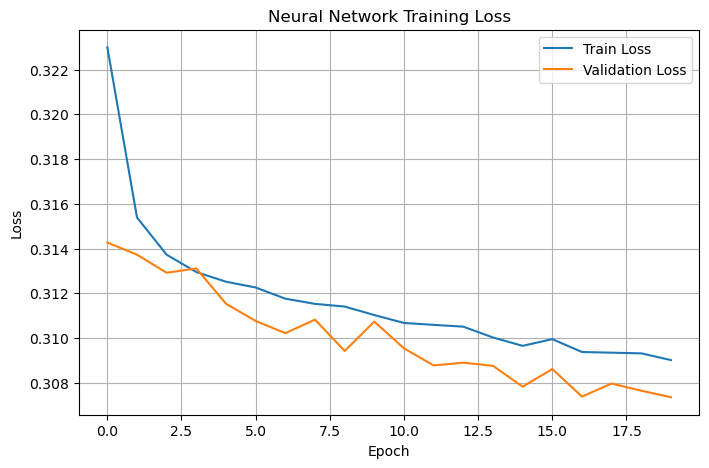

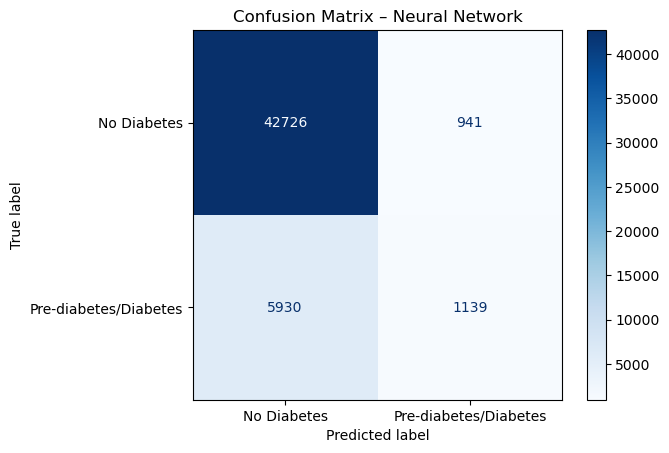

In [8]:
# TENSORFLOW/KERAS

import tensorflow as tf
from keras import layers, models

print("\n--- Starting Model 1: Neural Network ---")
input_dim = X_train.shape[1]

# Define the model
model = models.Sequential([
    layers.Input(shape=(input_dim,)), 
    layers.Dense(64, activation='relu'), 
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(2, activation='softmax') 
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    verbose = 1
)

# Evaluate the model
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Neural Network Accuracy: {acc:.4f}")


# Accuracy Plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Neural Network Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss Plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Neural Network Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


# Confusion
ConfusionMatrixDisplay.from_predictions(
    y_test,
    nn_y_proba.argmax(axis=1),  # Convert softmax → class index
    display_labels=['No Diabetes', 'Pre-diabetes/Diabetes'],
    cmap='Blues'
)
plt.title("Confusion Matrix – Neural Network")
plt.show()



--- Starting Model 2: Random Forest ---
Random Forest Accuracy: 0.8278


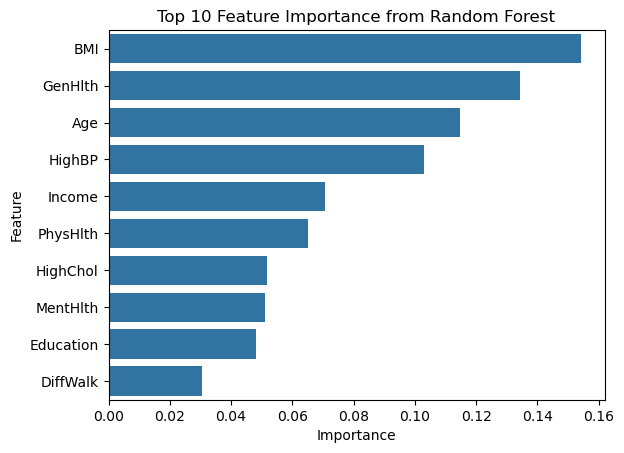

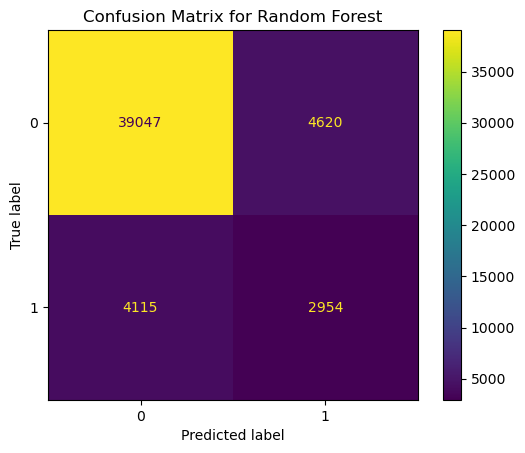

In [73]:
# RANDOM FOREST CLASSIFIER

from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier


# Initialize and train
rf_base = RandomForestClassifier(
 n_estimators=300,
 max_depth=20,
 class_weight="balanced",
 random_state=42
)

rf = OneVsRestClassifier(rf_base)
rf.fit(X_train, y_train)
val_acc_rf = rf.score(X_val, y_val)
y_pred_rf = rf.predict(X_test)
rf_acc = np.mean(y_pred_rf == y_test)
print(f"Random Forest Accuracy: {rf_acc:.4f}")

# Importance Plot
importances = rf.estimators_[0].feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title("Top 10 Feature Importance from Random Forest")
plt.show()

# Confusion Matrix Plot
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Confusion Matrix for Random Forest")
plt.show()